In [1]:
import numpy as np
from sympy import *
from pylab import *
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython.display import display, Math
plt.rcParams["figure.figsize"] = (12,8)
plt.rcParams['font.size'] = 10
plt.rcParams['legend.fontsize'] = 10

The **Helmholtz equation**:

$\qquad\quad\displaystyle\frac{d^2 u}{dx^2} + k^2 u = f(x)$

In the context of finite difference methods, this equation can be discretized using a spatial grid with spacing $h$.     
The second derivative $\frac{d^2 u}{dx^2}$ is approximated as:

$\qquad\quad\displaystyle\frac{d^2 u}{dx^2} \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}$

Substituting this approximation into the Helmholtz equation, we get the following discrete equation:

$\qquad\quad\displaystyle\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + k^2 u_i = f_i$

Multiplying through by $h^2$ to eliminate the denominator:

$\qquad\quad\displaystyle u_{i-1} - 2u_i + u_{i+1} + h^2 k^2 u_i = h^2 f_i$

Then                                                                                                                                                       
$\qquad\quad\displaystyle u_{i-1} + ( h^2 k^2 - 2) u_i + u_{i+1} = h^2 f_i$

This is the finite difference equation for each interior point in your spatial grid.                                         
The boundary points will still follow the prescribed boundary conditions.

This can be expressed in matrix form as follows:

$ \qquad\quad\displaystyle \underbrace{\begin{pmatrix} (h^2k^2  - 2) & 1 & 0 & \cdots & 0 \\ 1 & ( h^2k^2 - 2) & 1 & \cdots & 0 \\ 0 & 1 & ( h^2k^2 - 2) & \cdots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & 0 & \cdots & ( h^2k^2 - 2) \end{pmatrix}}_{\equiv\text{ A}} \ \underbrace{\begin{pmatrix} u_1 \\ u_2 \\ u_3 \\ \vdots \\ u_N \end{pmatrix}}_{\equiv\text{ u}} = \underbrace{h^2 \begin{pmatrix} f_1 \\ f_2 \\ f_3 \\ \vdots \\ f_N \end{pmatrix}}_{\equiv\text{ b}} $

The corresponding tridiagonal matrix form becomes :                                                                                
$\qquad\qquad\displaystyle  A \mathbf{u} = \mathbf{b} $

----

To find the **exact solution** to the **1D Helmholtz equation** with a source term,

$ \qquad\quad\displaystyle \frac{d^2 u}{dx^2} + k^2 u = f(x), \quad x \in (0, L)$

with boundary conditions $ u(0) = u(L) = 0$, we proceed using **eigenfunction expansion** (Fourier sine series).


We assume $f(x)$ and the solution $u(x)$ can be expanded in terms of the **eigenfunctions** of the Laplacian on $[0, L]$ with Dirichlet BCs:

$ \qquad\quad\displaystyle \phi_n(x) = \sin\left(\frac{n\pi x}{L}\right), \quad n = 1, 2, 3, \ldots $

These satisfy:

$ \qquad\quad\displaystyle \frac{d^2 \phi_n}{dx^2} = -\left(\frac{n\pi}{L}\right)^2 \phi_n(x)$

We expand:

$ \qquad\quad\displaystyle f(x) = \sum_{n=1}^{\infty} f_n \phi_n(x), \quad \text{with } f_n = \frac{2}{L} \int_0^L f(x) \sin\left(\frac{n\pi x}{L}\right) dx $

and assume:

$ \qquad\quad\displaystyle u(x) = \sum_{n=1}^{\infty} u_n \phi_n(x) $

Substituting into the Helmholtz equation:

$ \qquad\quad\displaystyle \sum_{n=1}^{\infty} \left[-\left(\frac{n\pi}{L}\right)^2 + k^2\right] u_n \phi_n(x) = \sum_{n=1}^{\infty} f_n \phi_n(x) $

Using orthogonality, we equate coefficients:

$ \qquad\quad\displaystyle \begin{align} u_n &= \frac{f_n}{k^2 - \left(\frac{n\pi}{L}\right)^2} \\ u(x) &= \sum_{n=1}^{\infty} \left( \frac{f_n}{k^2 - \left(\frac{n\pi}{L}\right)^2} \right) \sin\left( \frac{n\pi x}{L} \right) \end{align} $

If $ \displaystyle f(x) = \sin\left(\frac{m\pi x}{L}\right)$,                                                                                                       
then only one term contributes:

$ \qquad\quad\displaystyle f_n = \begin{cases} 1 & \text{if } n = m \\ 0 & \text{otherwise} \end{cases} \quad \Rightarrow \quad u(x) = \frac{1}{k^2 - \left(\frac{m\pi}{L}\right)^2} \sin\left( \frac{m\pi x}{L} \right) $

---

Let $ (L = 1, m = n)$ :

Then

$ \qquad\quad\displaystyle f(x) = \sin(\pi x) \quad \Rightarrow \quad u(x) = \frac{\sin(n \pi x)}{k^2 - (n\pi)^2} $

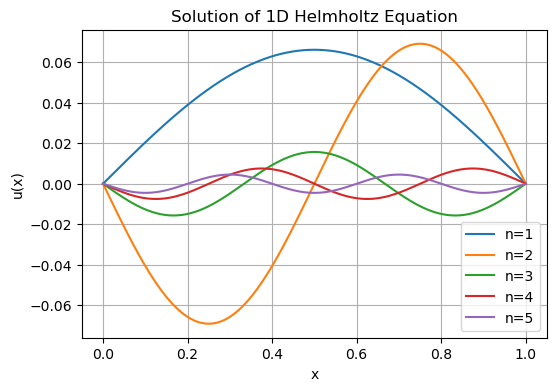

In [2]:
def helmholtz_eqn(x, h, k_val, f_func, boundaryConditions):
    N = len(x)
    f_vec = f_func(x,n)
    A = np.zeros((N, N))
    b = np.zeros(N)

    for i in range(1, N-1):
        A[i, i-1] = 1
        A[i, i]   = k_val**2 * h**2 - 2
        A[i, i+1] = 1
        b[i] = h**2 * f_vec[i]

    A[ 0, 0]  = 1
    A[-1, -1] = 1
    b[0]      = boundaryConditions[0]
    b[-1]     = boundaryConditions[1]
    return np.linalg.solve(A, b)

def helmholtz_exact(x, k, L, m ):
    return np.sin(m * np.pi * x / L) / ( k**2 - (m * np.pi / L)**2)

L  = 1
h  = 0.0025
N  = 5
x  = np.arange(0, L + h, h)
f  = lambda x,n : np.sin(n * np.pi * x)
k  = 5                       # wave number
bC = [0, 0]                  # Dirichlet boundary conditions: u(0) = u(L) = 0
plt.figure(figsize=(6,4))
for n in range(1, N+1):
    u = helmholtz_eqn(x, h, k, f, bC)
    u_exact = helmholtz_exact(x, k, L, n )
    plt.plot(x, u, label=f"n={n}")
    #plt.plot(x, u_exact, 'k--')
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Solution of 1D Helmholtz Equation")
plt.grid(True)
plt.legend()
plt.show()

---

<span style="color:red">Substitute $u(r,\theta,t)=U(r,\theta)T(t)$ into the wave eqn, 

<span style="color:red">$\quad \begin{align} u_{tt}=c^2\left( u_{rr}+\frac{1}{r}u_r+\frac{1}{r^2}u_{\theta\theta}\right) \end{align}$

<span style="color:red">in order to seperate it into the two equations

<span style="color:red">$\qquad \begin{align}  \nabla^2U + \lambda^2U=0 \\ T" + \lambda^2 c^2T=0 \end{align}$

We are given the **2D wave equation in polar coordinates**:

$ \qquad u_{tt} = c^2 \left( u_{rr} + \frac{1}{r} u_r + \frac{1}{r^2} u_{\theta\theta} \right)$

and asked to use **separation of variables** with:

$ \qquad u(r, \theta, t) = U(r, \theta) T(t)$


#####  Plug into the wave equation
                                                                                                     
$\begin{align}L.H.S. :  \qquad  u_{tt} = U(r, \theta) \, T''(t) \end{align}$                                                                                         
$\begin{align}R.H.S. :  \qquad  c^2 \left( u_{rr} + \frac{1}{r} u_r + \frac{1}{r^2} u_{\theta\theta} \right) = c^2 \left( T(t) \cdot \left( U_{rr} + \frac{1}{r} U_r + \frac{1}{r^2} U_{\theta\theta} \right) \right) \end{align}$

Put both sides together :

$ \qquad\begin{align} U(r, \theta) T''(t) = c^2 T(t) \left( U_{rr} + \frac{1}{r} U_r + \frac{1}{r^2} U_{\theta\theta} \right)  \end{align} $

Divide both side by $ c^2 U(r,\theta) T(t) $
 
$\qquad \begin{align} \frac{T''(t)}{c^2 T(t)} &= \frac{U_{rr} + \frac{1}{r} U_r + \frac{1}{r^2} U_{\theta\theta}}{U(r,\theta)} &= -\lambda^2  \\ \frac{T''(t)}{c^2 T(t)} &= \frac{\nabla^2 U(r,\theta)}{U(r,\theta)} &= -\lambda^2  \end{align} $

Now, the left-hand side is purely a function of $t$, and the right-hand side is purely a function of $r, \theta$.     
Hence both sides must be equal to a constant , let's call it $-\lambda^2$:

#####  Separated Equations:

#### $\qquad\begin{array}{|c|c|} \hline \textbf{Helmholtz equation} & \textbf{Simple Harmonic Motion O.D.E.} \\ \hline \displaystyle \frac{\nabla^2 U(r,\theta)}{U(r,\theta)} = -\lambda^2 & \displaystyle \frac{T''(t)}{c^2 T(t)} = -\lambda^2 \\ \displaystyle \nabla^2 U(r,\theta) = -\lambda^2U(r,\theta) & \displaystyle T''(t) = -\lambda^2c^2 T(t) \\ \displaystyle \nabla^2 U(r,\theta) + \lambda^2U(r,\theta) = 0 & \displaystyle T''(t) + \lambda^2c^2 T(t) = 0 \\ \hline \end{array}$

These are the standard forms used in separation of variables for circular membrane vibrations, etc.

---

<span style="color:red">Substitute $U(r, \theta)=R(r)\Theta(\theta)$ into the Helmholtz BVP

<span style="color:red">$\qquad\begin{align} \nabla^2 U + \lambda^2 U = 0 \\  U(1, \theta) = 0 \end{align}$

<span style="color:red">$\quad$to get 

<span style="color:red">$\qquad\qquad\begin{align} r^2 R" + r R' + (\lambda^2r^2-n^2)R = 0 \\  R(1) = 0 \\  \Theta" + n^2\Theta = 0 \end{align}$

<span style="color:red">Why do we choose the separation constant to be $0, 1, 2, \dots $ ( which we decide to call $n^2$ )

We begin with the **Helmholtz equation in polar coordinates**:

$\qquad\begin{align} \nabla^2 U + \lambda^2 U = 0 \end{align}$

In polar coordinates, the Laplacian is:

$\qquad\begin{align} \nabla^2 U = \frac{\partial^2 U}{\partial r^2} + \frac{1}{r} \frac{\partial U}{\partial r} + \frac{1}{r^2} \frac{\partial^2 U}{\partial \theta^2} \end{align}$

So the equation becomes:

$\qquad\begin{align} \frac{\partial^2 U}{\partial r^2} + \frac{1}{r} \frac{\partial U}{\partial r} + \frac{1}{r^2} \frac{\partial^2 U}{\partial \theta^2} + \lambda^2 U = 0 \end{align}$

Let, $ U(r, \theta) = R(r)\Theta(\theta) $

Compute derivatives:

* $\frac{\partial U}{\partial r} = R'(r) \Theta(\theta)$
* $\frac{\partial^2 U}{\partial r^2} = R''(r) \Theta(\theta)$
* $\frac{\partial^2 U}{\partial \theta^2} = R(r) \Theta''(\theta)$

Substitute into the Helmholtz equation:

$\qquad\begin{align} R''(r) \Theta(\theta) + \frac{1}{r} R'(r) \Theta(\theta) + \frac{1}{r^2} R(r) \Theta''(\theta) + \lambda^2 R(r) \Theta(\theta) = 0 \end{align}$

$\qquad\begin{align} R''(r) \Theta(\theta) + \frac{1}{r} R'(r) \Theta(\theta) + \lambda^2 R(r) \Theta(\theta) = - \frac{1}{r^2} R(r) \Theta''(\theta) \end{align}$

Divide through by $R(r)\Theta(\theta)$:

$ \qquad\begin{align} \frac{R''(r)}{R(r)} + \frac{1}{r} \frac{R'(r)}{R(r)} + \lambda^2 &= -\frac{1}{r^2} \frac{\Theta''(\theta)}{\Theta(\theta)} \\ r^2\frac{R''(r)}{R(r)} + r \frac{R'(r)}{R(r)} + r^2\lambda^2 &= - \frac{\Theta''(\theta)}{\Theta(\theta)} = n^2 \end{align}$

Now, the left-hand side depends only on $r$, the right-hand side only on $\theta$,                                        
so both sides must equal a **constant**, which we call $n^2$.

$\qquad\begin{array}{|c|c|} \hline \textbf{Radial Equation} & \textbf{Angular Equation} \\ \hline \displaystyle {r^2 \frac{R''(r)}{R(r)} + r \frac{R'(r)}{R(r)} + r^2 \lambda^2 = n^2} & \displaystyle {- \frac{\Theta''(\theta)}{\Theta(\theta)} = n^2} \\ \displaystyle {r^2 R''(r) + r R'(r) + r^2 \lambda^2 R(r) = n^2 R(r)} & \displaystyle {\frac{\Theta''(\theta)}{\Theta(\theta)} = -n^2 } \\ \displaystyle {r^2 R''(r) + r R'(r) + r^2 \lambda^2 R(r) - n^2 R(r) = 0} & \displaystyle {\Theta''(\theta) = -n^2 \Theta(\theta) } \\  \hline \displaystyle {r^2 R''(r) + r R'(r) + \left( r^2 \lambda^2 - n^2 \right) R(r) = 0} & \displaystyle {\Theta''(\theta) + n^2 \Theta(\theta) = 0} \\ \hline \text{This is the Bessel differential equation of order } n & \text{General O.D.E. of Simple Harmonic Motion} \\ \hline \text{solution} : R(r) = a_n J_n(\lambda r) + b_n Y_n(\lambda r) &  \text{solution }: \Theta(\theta) = A \cos(n\theta) + B \sin(n\theta) \\ \hline \text{ Apply the Boundary Condition } & \text{ Periodic Solutions } \\  \displaystyle { U(1, \theta) = 0 \Rightarrow R(1)\Theta(\theta) = 0 \text{ for all } \theta} & \text{Since the angle } \theta\text{ is a periodic variable defined on }[0, 2\pi] \\  \text{We don't want the trivial solution }\Theta(\theta) = 0,  & \text{we require the solution }\Theta(\theta)\text{ to be satisfy }\Theta(\theta+2\pi)=\Theta(\theta) . \\  \text{ so we require }:R(1) =  a_n J_n(\lambda) + b_n Y_n(\lambda) = 0 & \text{which holds only if }n \text{ is an integer}. \\ \text{If we require the solution to be finite at the origin}, & \text{To ensure the physical and mathematical periodicity of the angular part,} \\ \text{then we must set }b_n = 0, \text{ because }Y_n(r) \to -\infty \text{ as }r \to 0. & \text{we must restrict }: n = 0, 1, 2, \dots  \\ \text{So we keep only }:  R(r) = a_n J_n(\lambda r), \quad \text{and } J_n(\lambda) = 0 & \text{And since }n^2 \text{ appears in the equation}, \\ \text{This means }\lambda \text{ must be a zero of the Bessel function }J_n. & \text{the separation constant is written as } n^2. \\ \hline \end{array}$

---

<span style="color:red">Solve 

<span style="color:red">$ \qquad\text{PDE} \quad u_{tt}=\nabla^2u \quad 0<r<1  $

<span style="color:red">$ \qquad\text{BC} \quad \ u(1,\theta,t)=0 \quad 0<t<\infty $

<span style="color:red">$ \qquad \begin{equation*} \text{IC} \quad\left\{\begin{array}{}  u(r,\theta,0) = 1-r^2 & \\ u_t(r,\theta,0) = 0 & \end{array}  \right.  \end{equation*} 0\le r\le 1 $

Assume a separable solution:

$\qquad u(r, \theta, t) = R(r)\Theta(\theta)T(t)$

Substitute into the wave equation:

$\qquad R\Theta T'' = \left( R'' + \frac{1}{r} R' + \frac{1}{r^2} R \Theta'' \right) T$

Divide by $R \Theta T$:

$\qquad\displaystyle \underbrace{\frac{T''}{T}}_{\equiv{-\lambda^2}} = \frac{R''}{R} + \frac{1}{r} \frac{R'}{R} + \frac{1}{r^2} \underbrace{\frac{\Theta''}{\Theta}}_{\equiv{-n^2}} $

$\qquad\displaystyle -\lambda^2 = \frac{R''}{R} + \frac{1}{r} \frac{R'}{R} - \frac{1}{r^2} n^2 $

$\qquad\displaystyle  r^2 R'' + r R' - n^2 R = -\lambda^2 r^2 R$

$\qquad\displaystyle r^2 R'' + r R' + \lambda^2 r^2 R  - n^2 R = 0 $

$\qquad\displaystyle r^2 R'' + r R' + (\lambda^2 r^2 - n^2)R = 0 $

This is the **Bessel equation**. The solution is : $ R(r) = a_n J_n(\lambda r) + b_n Y_n(\lambda r) $

Since $ \displaystyle Y_n(r) \to \infty$ as $r \to 0$, we discard it to ensure finiteness at $r = 0$. So : $ R(r) = a_n J_n(\lambda r) $

Apply the **boundary condition** $ \displaystyle u(1, \theta, t) = 0 \Rightarrow R(1) = 0$ :

$\qquad\displaystyle J_n(\lambda) = 0 \quad\Rightarrow\quad \lambda = j_{n,m}, \text{ the } m\text{-th zero of } J_n $ i.e.,  $j_{0,m}$ are the positive zeros of $J_0$

Given the initial condition $ u(r, \theta, 0) = 1 - r^2$, there's **no angular dependence**,                                   
so we only take the **$n = 0$** term : $ \displaystyle u(r, t) = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) \cos(j_{0,m} ct) $

Apply initial condition :  $\qquad\displaystyle  u(r, 0) = 1 - r^2$:

Fourier-Bessel expansion : $\qquad\displaystyle  1 - r^2 = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) $

The coefficients are : $\qquad\displaystyle  A_m = \frac{ \int_0^1 (1 - r^2) J_0(j_{0,m} r) r \, dr }{ \int_0^1 [J_0(j_{0,m} r)]^2 r \, dr } $

This gives the solution : $\qquad\displaystyle  \boxed{u(r, t) = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) \cos(j_{0,m} ct)} $

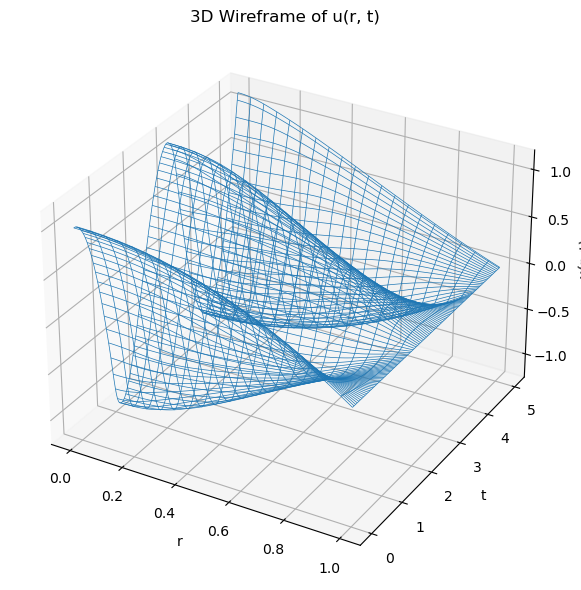

In [11]:
from scipy.special import jn_zeros, j0
from scipy.integrate import quad

M = 10                 # number of terms in series
c = 1.0                # wave speed
r_vals = np.linspace(0, 1, 100)
t_vals = np.linspace(0, 5, 200)
R, T = np.meshgrid(r_vals, t_vals)
j_zeros = jn_zeros(0, M)

def A_m(m):
    j = j_zeros[m]
    numerator = quad(lambda r: (1 - r**2) * j0(j * r) * r, 0, 1)[0]
    denominator = quad(lambda r: (j0(j * r))**2 * r, 0, 1)[0]
    return numerator / denominator

A = np.array([A_m(m) for m in range(M)])
U = np.zeros_like(R)
for m in range(M):
    j = j_zeros[m]
    U += A[m] * j0(j * R) * np.cos(j * c * T)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(R, T, U, rstride=2, cstride=5, linewidth=0.5)
ax.set_xlabel('r')
ax.set_ylabel('t')
ax.set_zlabel('u(r, t)')
ax.set_title('3D Wireframe of u(r, t)')
plt.tight_layout()
plt.show()

---

<span style="color:red">Solve 

<span style="color:red">$ \qquad\text{PDE} \quad u_{tt}=\nabla^2u \quad 0<r<1  $

<span style="color:red">$ \qquad\text{BC} \quad \ u(1,\theta,t)=0 \quad 0<t<\infty $

<span style="color:red">$ \qquad\begin{equation*} \text{IC} \quad\left\{\begin{array}{}  u(r,\theta,0) = J_0(2.4 r) & \\ u_t(r,\theta,0) = 0 & \end{array}  \right.  \end{equation*} 0\le r\le 1 $

##### 1. **Use separation of variables**:

Assume:  $\qquad\displaystyle u(r,\theta,t) = R(r)\Theta(\theta)T(t)$

$\qquad$→ We get the same Bessel differential equation for $R(r)$, with solutions:

$\qquad\qquad\displaystyle R(r) = J_n(\lambda r), \quad \text{and } \Theta(\theta) = \cos(n\theta), \sin(n\theta) $

##### 2. **Initial condition has no angular dependence**, so $n = 0$, and:

$\qquad\displaystyle u(r,t) = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) \cos(j_{0,m} ct) $

##### 3. **Match the Initial Condition**

Given : $\qquad\displaystyle u(r,0) = J_0(2.4\, r) $

Compare this with the general solution:

$\qquad\displaystyle u(r,0) = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) $

That is, **$J_0(2.4\, r)$ is already an eigenfunction** $J_0(j_{0,m} r)$ where $j_{0,m} = 2.4$.                          
So, $2.4$ is **very close to the first zero** of $J_0$, which is $\displaystyle j_{0,1} \approx 2.4048$. Therefore, $J_0(2.4 r) \approx J_0(j_{0,1} r)$. 

Thus the expansion becomes:                                                
$\qquad\displaystyle u(r,t) = J_0(2.4\, r) \cos(2.4\, ct) \approx J_0(j_{0,1} r)\, \cos(j_{0,1} ct) \quad\text{with } j_{0,1} \approx 2.4048 $

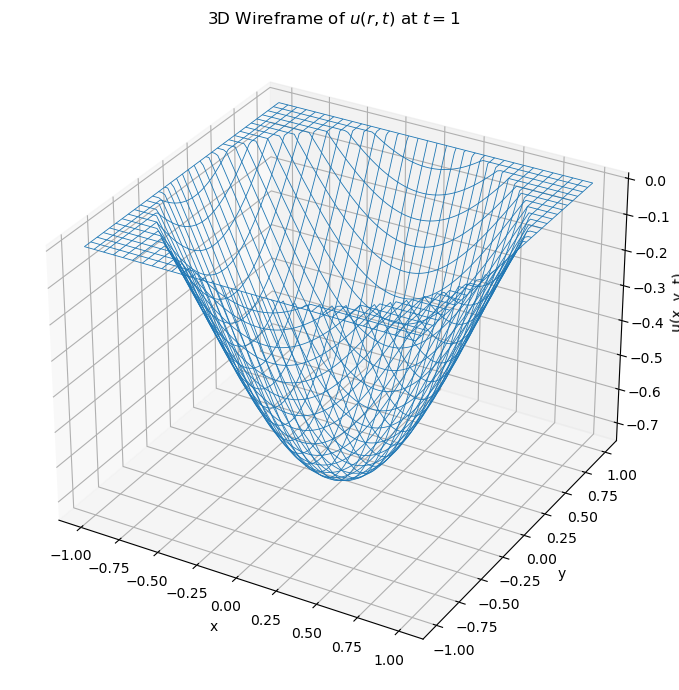

In [14]:
t = 1.0
c = 1.0
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
mask = R <= 1.0
U = np.zeros_like(R)
U[mask] = (j0(2.4 * R[mask]) * np.cos(2.4 * c * t) )

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, U, rstride=3, cstride=3, linewidth=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x, y, t)')
ax.set_title('3D Wireframe of $u(r, t)$ at $t = 1$')
plt.tight_layout()
plt.show()

---

<span style="color:red">Solve 

<span style="color:red">$ \qquad\text{PDE} \quad u_{tt}=\nabla^2u \quad 0<r<1  $

<span style="color:red">$ \qquad\text{BC} \quad \ u(1,\theta,t)=0 \quad 0<t<\infty $

<span style="color:red">$ \qquad\begin{equation*} \text{IC} \quad\left\{\begin{array}{}  u(r,\theta,0) = J_0(2.4 r) - 0.5 J_0(8.65r) + 0.25 J_0(14.93r) & \\ u_t(r,\theta,0) = 0 & \end{array}  \right.  \end{equation*} 0\le r\le 1 $

<span style="color:red">What is the highest frequency in the vibration?

We are given a **radial wave equation** with the following data:

##### 1. **Step-by-step Solution**:

We assume the standard **separable form** solution for a vibrating circular membrane:

$\qquad\displaystyle u(r, t) = \sum_{m=1}^\infty A_m J_0(j_{0,m} r) \cos(j_{0,m} ct) $

Here, $j_{0,m}$ are the **positive zeros** of the Bessel function $J_0$, and the time dependence is $\cos(j_{0,m} ct)$.

##### 2. **Matching the Initial Condition**

We are given:

$\qquad\displaystyle u(r, 0) = J_0(2.4 r) - 0.5 J_0(8.65 r) + 0.25 J_0(14.93 r) $

Thus, the solution becomes:

### $\qquad\displaystyle \boxed{u(r,t) = J_0(2.4\, r) \cos(2.4\, ct) - 0.5 J_0(8.65\, r) \cos(8.65\, ct) + 0.25 J_0(14.93\, r) \cos(14.93\, ct)} $

@ The frequency is determined by the coefficient in the cosine term. So the **highest frequency** is **14.93**.

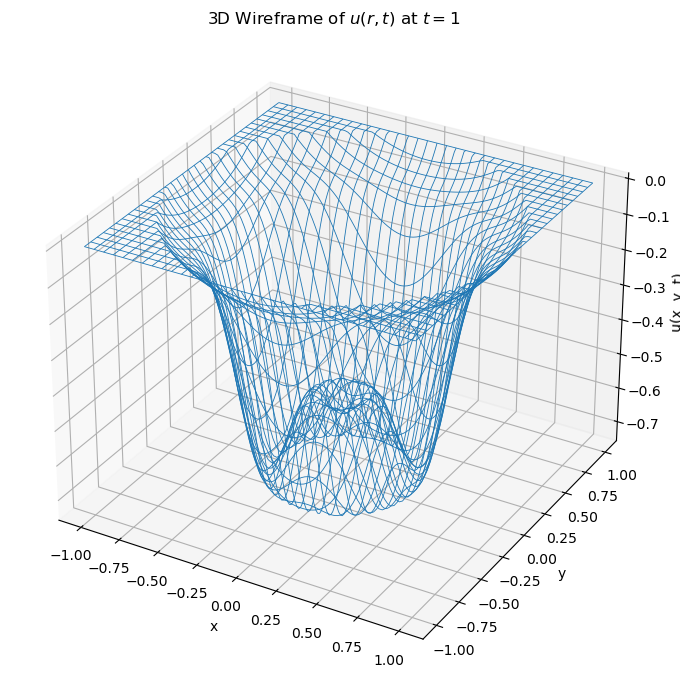

In [12]:
t = 1.0
c = 1.0
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
mask = R <= 1.0
U = np.zeros_like(R)
U[mask] = (j0(2.4 * R[mask]) * np.cos(2.4 * c * t) -
           0.5 * j0(8.65 * R[mask]) * np.cos(8.65 * c * t) +
           0.25 * j0(14.93 * R[mask]) * np.cos(14.93 * c * t))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, U, rstride=3, cstride=3, linewidth=0.6)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x, y, t)')
ax.set_title('3D Wireframe of $u(r, t)$ at $t = 1$')
plt.tight_layout()
plt.show()

---

<span style="color:red">Graph the following functions for $ 0\le r\le 1  $:                                                                                 
<span style="color:red">$ \ \ \ (a) \ J_0 (5.52r) \qquad\qquad (b) \ J_0(14.93r) $

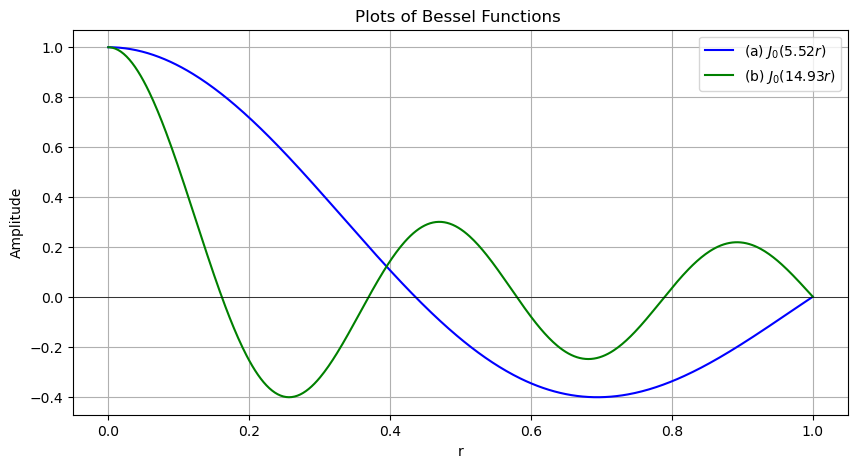

In [3]:
r   = np.linspace(0, 1, 500)
f_a = j0(5.52  * r)
f_b = j0(14.93 * r)

plt.figure(figsize=(10, 5))
plt.plot(r, f_a, color='blue' , label=r'(a) $J_0(5.52r)$')
plt.plot(r, f_b, color='green', label=r'(b) $J_0(14.93r)$')
plt.xlabel('r')
plt.ylabel('Amplitude')
plt.grid(True)
plt.axhline(0, color='black', lw=0.5)
plt.legend()
plt.title('Plots of Bessel Functions ')
plt.show()